In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pickle
import networkx as nx

plt.style.use("seaborn-v0_8")
plt.rcParams['axes.grid'] = False

## 1) Setup and data discovery

We import packages and locate the pickled time-series files on disk.

In [2]:
DATA_DIR = "../../../Data/"   

print("Files found:")
print(glob.glob(os.path.join(DATA_DIR, "*.pkl")))

Files found:
['../../../Data\\rsfMRI_utils.pkl']


## 2) Load parcel time series (per subject, per session) and Yeo7 network labels

Each file contains a dictionary of sessions → time-series matrix $T\times N$ (timepoints × parcels).

In [3]:
data_all = {}

files = sorted(glob.glob(os.path.join(DATA_DIR, "*/rsfMRI/*_TC_Schaefer.pkl")))
if files:
    file = files[0]
    subj_id = os.path.basename(file).split("_")[0]
    with open(file, "rb") as f:
        data_all[subj_id] = pickle.load(f)

print(f"Loaded {len(data_all)} subject(s): {list(data_all.keys())}")

Loaded 1 subject(s): ['003GNV']


In [4]:
# Look at first subject
first_subj = list(data_all.keys())[0]
print("Subject ID:", first_subj)

print("\nSessions available:")
print(data_all[first_subj].keys())


Subject ID: 003GNV

Sessions available:
dict_keys(['V01_100', 'V01_200', 'V01_400', 'V01_800', 'V03_100', 'V03_200', 'V03_400', 'V03_800', 'V04_100', 'V04_200', 'V04_400', 'V04_800', 'V05_100', 'V05_200', 'V05_400', 'V05_800', 'V06_100', 'V06_200', 'V06_400', 'V06_800', 'V07_100', 'V07_200', 'V07_400', 'V07_800', 'V08_100', 'V08_200', 'V08_400', 'V08_800', 'V09_100', 'V09_200', 'V09_400', 'V09_800', 'V10_100', 'V10_200', 'V10_400', 'V10_800', 'V11_100', 'V11_200', 'V11_400', 'V11_800', 'V12_100', 'V12_200', 'V12_400', 'V12_800', 'V13_100', 'V13_200', 'V13_400', 'V13_800', 'V14_100', 'V14_200', 'V14_400', 'V14_800', 'V15_100', 'V15_200', 'V15_400', 'V15_800'])


In [5]:
with open("../../../Data/rsfMRI_utils.pkl", "rb") as f:
    rsfMRI_utils = pickle.load(f)

print(rsfMRI_utils.keys())

dict_keys(['AudROI', 'AudROIoverlap', 'FDindices', 'PCidx', 'yeo7'])


In [6]:
yeo_info = rsfMRI_utils["yeo7"][200]

yeo_rois = np.array(yeo_info["yeoROIs"]).astype(int).ravel()
print("Yeo labels length:", len(yeo_rois))
print("Unique network ids:", np.unique(yeo_rois))

Yeo labels length: 219
Unique network ids: [1 2 3 4 5 6 7 8 9]


In [7]:
# Yeo7 canonical names
network_names = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default Mode"
]

## 3) Attempt with partial correlations

In [8]:
# --- pick your subject/session ---
subj = first_subj          # or "008GNV"
sess = 'V01_200'         

# --- load labels (1..9) ---
yeo_info = rsfMRI_utils["yeo7"][200]
yeo_rois = np.array(yeo_info["yeoROIs"]).astype(int).ravel()



# --- compute FC ---
ts = data_all[subj][sess]  

# center time series
X = ts - ts.mean(axis=0)

# covariance (N x N)
cov = np.cov(X, rowvar=False)

T, N = ts.shape

# regularize a bit for stability if N is large or T is small
lam = 1e-3
cov_reg = cov + lam * np.eye(N)

prec = np.linalg.inv(cov_reg)

# partial corr from precision matrix
d = np.sqrt(np.diag(prec))
fc = -prec / np.outer(d, d)
np.fill_diagonal(fc, 1.0)


np.fill_diagonal(fc, np.nan)                # ignore diagonal in averages

assert fc.shape[0] == len(yeo_rois), (fc.shape, len(yeo_rois))

# --- cortical-only mask: keep networks 1..7, drop 8 & 9 (subcortical) ---
cortical_mask = yeo_rois <= 7

fc_cx = fc[np.ix_(cortical_mask, cortical_mask)]
yeo_cx = yeo_rois[cortical_mask]

print("Cortical FC shape:", fc_cx.shape)
print("Unique cortical networks:", np.unique(yeo_cx))


Cortical FC shape: (200, 200)
Unique cortical networks: [1 2 3 4 5 6 7]


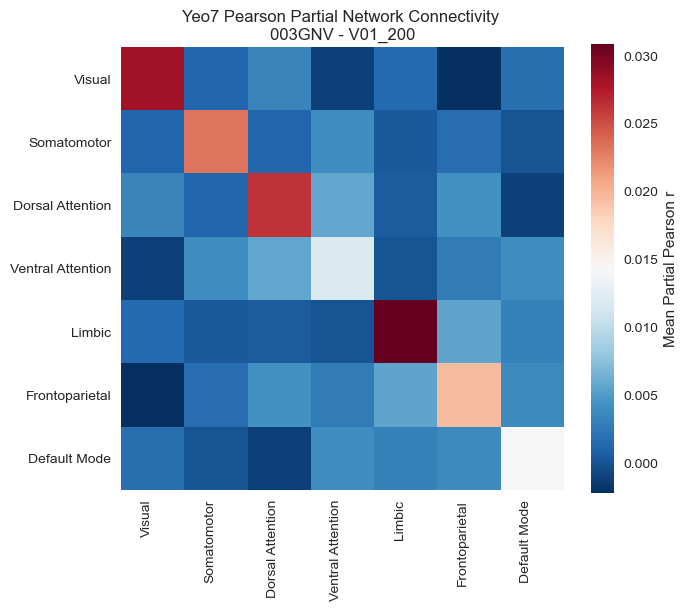

In [9]:
# Fisher transform first
fc_z = np.arctanh(fc_cx)

# Make sure diagonal is NaN
np.fill_diagonal(fc_z, np.nan)

nets = np.arange(1, 8)
netmat = np.full((7, 7), np.nan)

for i, ni in enumerate(nets):
    idx_i = np.where(yeo_cx == ni)[0]
    
    for j, nj in enumerate(nets):
        idx_j = np.where(yeo_cx == nj)[0]
        
        block = fc_z[np.ix_(idx_i, idx_j)]
        
        # If within-network, remove diagonal entries
        if i == j:
            block = block[~np.eye(len(idx_i), dtype=bool)]
        
        netmat[i, j] = np.nanmean(block)

# Convert back to r for interpretability
netmat_r = np.tanh(netmat)


plt.figure(figsize=(7, 6))
plt.imshow(netmat_r, cmap="RdBu_r")
plt.colorbar(label="Mean Partial Pearson r")

plt.xticks(range(7), network_names, rotation=90, ha="right")
plt.yticks(range(7), network_names)

plt.title(f"Yeo7 Pearson Partial Network Connectivity \n{subj} - {sess}")
plt.tight_layout()
plt.show()
